In [1]:
import astra
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage
import sys 
sys.path.append('..')
import amglib.readers as rd
import amglib.imageutils as amg
import amglib.widgets as aw

from scipy.ndimage import shift

import importlib

import astrautils as au

In [2]:
importlib.reload(au)

<module 'astrautils' from 'C:\\Users\\kaestner\\git\\scripts\\python\\astra\\astrautils.py'>

In [3]:
astra.test()

ASTRA Toolbox v2.3.1
Getting GPU info... GPU #0: Quadro RTX 4000, with 8191MB, CUDA compute capability 7.5
Testing basic CPU 2D functionality... Ok
Testing basic CUDA 2D functionality... Ok
Testing basic CUDA 3D functionality... Ok


# Load and normalize

In [4]:
path = 'D:/Kaestner/P20250668/02_rawdata/01_Config1/01_Calibration/'
proj0 = rd.read_images(path+'cal_{0:05d}.fits',first=1, last=361)
ob0 = rd.read_images(path+'ob_{0:05d}.fits',first=1, last=5).mean(axis=0)
dc0 = rd.read_images(path+'dc_{0:05d}.fits',first=1, last=5).mean(axis=0)

  0%|          | 0/361 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

In [7]:
proj = proj0-dc0
proj[proj<1]=1
o = ob0-dc0
o[o<1]=1
proj = proj/o 

In [11]:
N = 4
p_small0 = proj[::N,::N,::N]
p_small = np.transpose(p_small0,(1,0,2))

In [12]:
p_small.shape

(544, 91, 448)

# Setup recon

In [5]:
z,y,x = proj.shape
print(f"z = {z}")
print(f"y = {y}")
print(f"x = {x}")


angles = np.linspace(0, 2 * np.pi, num=z, endpoint=True)

zoom_factor = 0.25
# p_small = scipy.ndimage.zoom(proj, (zoom_factor,zoom_factor,zoom_factor), order=3) 
N = 4
p_small = proj[::N,::N,::N]

# Distances (in voxel units)
# detector_pixel_size = 0.139/zoom_factor
detector_pixel_size = 0.139*N

# det_rows, det_cols = y, x
det_rows, det_cols = p_small.shape[1:]
SOD = 395                  # Source to object distance
SDD = 1327                  # Source to detector distance
det_distance = SDD-SOD                  # Source to detector distance
source_distance = 395                # Source to origin distance

vol_geom = astra.create_vol_geom(p_small.shape[1], p_small.shape[2], p_small.shape[0])
# vol_geom = astra.create_vol_geom(p_small.shape[1], p_small.shape[2], p_small.shape[2])

NameError: name 'proj' is not defined

In [135]:
detector_geom = {'DetectorRowCount': p_small.shape[1], 'DetectorColCount': p_small.shape[2], 
                 'DetectorSpacing': (detector_pixel_size, detector_pixel_size)}                                                                                   

# Generate projection geometry
# proj_geom = astra.create_proj_geom('cone', detector_geom['DetectorSpacing'][0], detector_geom['DetectorSpacing'][1],
#                                    p_small.shape[1], p_small.shape[2], angles, source_distance, det_distance)

# proj_geom = astra.create_proj_geom('cone', 
#                                    detector_spacing_x = detector_geom['DetectorSpacing'][0], 
#                                    detector_spacing_y = detector_geom['DetectorSpacing'][1], 
#                                    det_row_count      = detector_geom['DetectorRowCount'], 
#                                    det_col_count      = detector_geom['DetectorColCount'], 
#                                    angles             = angles, 
#                                    source_origin      = source_distance, 
#                                    origin_det         = det_distance)

proj_geom = astra.create_proj_geom('cone', 
                                   detector_geom['DetectorSpacing'][0], 
                                   detector_geom['DetectorSpacing'][1], 
                                   detector_geom['DetectorRowCount'], 
                                   detector_geom['DetectorColCount'], 
                                   angles, 
                                   source_distance, 
                                   det_distance)

In [136]:
vol_id = astra.data3d.create('-vol', vol_geom, p_small)
proj_id, projections = astra.creators.create_sino3d_gpu(vol_id, proj_geom, vol_geom)

In [137]:
## Run the reconstruction algorithm
rec_geom = astra.create_vol_geom(p_small.shape[2], p_small.shape[2], p_small.shape[1])
rec_id = astra.data3d.create('-vol', rec_geom)
cfg = astra.astra_dict('FDK_CUDA')
cfg['ReconstructionDataId'] = rec_id
cfg['ProjectionDataId']     = proj_id
cfg['ProjectorId']          = astra.create_projector('cuda3d', proj_geom, vol_geom)
cfg['option']               = { 'MinConstraint': 0, 'MaxConstraint': 1 }

In [138]:
alg_id = astra.algorithm.create(cfg)
astra.algorithm.run(alg_id)
reconstruction = astra.data3d.get(rec_id)

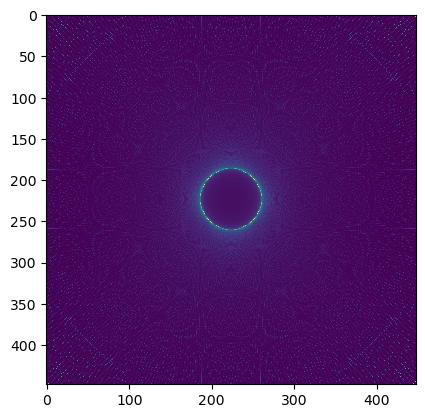

In [141]:
plt.imshow(reconstruction[reconstruction.shape[0] // 2], interpolation="none", cmap='viridis')
# plt.clim(0, 500)
plt.show()
#plt.savefig("reconstruction.png", dpi=300)
plt.imsave("reconstruction_slice.png", reconstruction[reconstruction.shape[0] // 2], cmap='viridis')

In [ ]:
## Clean-up
astra.algorithm.delete(alg_id)
astra.data3d.delete([vol_id, proj_id, rec_id])
astra.projector.delete([proj_id, projections])   

# Chat example

In [122]:
import astra
import numpy as np

n = 4
pix_size = 0.139*n  # mm
SOD = 395.0       # mm
SDD = 1300.0      # mm


p_small = np.ascontiguousarray(proj[::n,::n,::n].astype(np.float32).copy())

angles = np.linspace(0, 2*np.pi, p_small.shape[0], endpoint=False)

N, H, W = p_small.shape

In [123]:
def build_geometry_vectors(angles, SOD, SDD, H, W, pix_size):
    u_size = W * pix_size
    v_size = H * pix_size
    vectors = []

    for angle in angles:
        R = np.array([
            [np.cos(angle), -np.sin(angle), 0],
            [np.sin(angle),  np.cos(angle), 0],
            [0,              0,             1]
        ])

        # Source position (rotate by angle)
        src = R @ np.array([-SOD, 0, 0])
        det_center = R @ np.array([SDD - SOD, 0, 0])

        # Detector directions
        u = R @ np.array([0, pix_size, 0])   # horizontal
        v = R @ np.array([0, 0, pix_size])   # vertical

        vectors.append(np.concatenate([src, det_center, u, v]))

    return np.array(vectors)

geometry_vectors = build_geometry_vectors(angles, SOD, SDD, H, W, pix_size)


In [124]:
proj_geom = astra.create_proj_geom('cone_vec', H, W, geometry_vectors)
vol_size = 256
vol_geom = astra.create_vol_geom(vol_size, vol_size, vol_size)

In [127]:
p_small = p_small.astype(np.float32).copy()  # ensure float32

proj_id = astra.data3d.create('-proj3d', proj_geom, p_small)
rec_id = astra.data3d.create('-vol', vol_geom)

ValueError: The dimensions of the data (91, 544, 448) do not match those specified in the geometry (544, 91, 448)

In [114]:
proj_geom

{'type': 'cone_vec',
 'DetectorRowCount': 544,
 'DetectorColCount': 448,
 'Vectors': array([[-395.        ,    0.        ,    0.        , ...,    0.        ,
            0.        ,    0.556     ],
        [-394.05882256,  -27.25150204,    0.        , ...,    0.        ,
            0.        ,    0.556     ],
        [-391.23977538,  -54.37313826,    0.        , ...,    0.        ,
            0.        ,    0.556     ],
        ...,
        [-386.55629249,   81.23566172,    0.        , ...,    0.        ,
            0.        ,    0.556     ],
        [-391.23977538,   54.37313826,    0.        , ...,    0.        ,
            0.        ,    0.556     ],
        [-394.05882256,   27.25150204,    0.        , ...,    0.        ,
            0.        ,    0.556     ]], shape=(91, 12))}

In [112]:
W

448

# Tutorial example

In [128]:
from __future__ import division
 
import numpy as np
from os import mkdir
from os.path import join, isdir
from imageio import get_writer
 
import astra
 
# Configuration.
distance_source_origin = 300  # [mm]
distance_origin_detector = 100  # [mm]
detector_pixel_size = 1.05  # [mm]
detector_rows = 200  # Vertical size of detector [pixels].
detector_cols = 200  # Horizontal size of detector [pixels].
num_of_projections = 180
angles = np.linspace(0, 2 * np.pi, num=num_of_projections, endpoint=False)
output_dir = 'dataset'
 
# Create phantom.
vol_geom = astra.creators.create_vol_geom(detector_cols, detector_cols,
                                          detector_rows)
phantom = np.zeros((detector_rows, detector_cols, detector_cols))
hb = 110  # Height of beam [pixels].
wb = 40   # Width of beam [pixels].
hc = 100  # Height of cavity in beam [pixels].
wc = 30   # Width of cavity in beam [pixels].
phantom[detector_rows // 2 - hb // 2 : detector_rows // 2 + hb // 2,
        detector_cols // 2 - wb // 2 : detector_cols // 2 + wb // 2,
        detector_cols // 2 - wb // 2 : detector_cols // 2 + wb // 2] = 1
phantom[detector_rows // 2 - hc // 2 : detector_rows // 2 + hc // 2,
        detector_cols // 2 - wc // 2 : detector_cols // 2 + wc // 2,
        detector_cols // 2 - wc // 2 : detector_cols // 2 + wc // 2] = 0
phantom[detector_rows // 2 - 5 :       detector_rows // 2 + 5,
        detector_cols // 2 + wc // 2 : detector_cols // 2 + wb // 2,
        detector_cols // 2 - 5 :       detector_cols // 2 + 5] = 0
phantom_id = astra.data3d.create('-vol', vol_geom, data=phantom)
 
# Create projections. With increasing angles, the projection are such that the
# object is rotated clockwise. Slice zero is at the top of the object. The
# projection from angle zero looks upwards from the bottom of the slice.
proj_geom = \
  astra.create_proj_geom('cone', 1, 1, detector_rows, detector_cols, angles,
                         (distance_source_origin + distance_origin_detector) /
                         detector_pixel_size, 0)
projections_id, projections = \
  astra.creators.create_sino3d_gpu(phantom_id, proj_geom, vol_geom)
projections /= np.max(projections)
 
# Apply Poisson noise.
projections = np.random.poisson(projections * 10000) / 10000
projections[projections > 1.1] = 1.1
projections /= 1.1
 
# Save projections.
if not isdir(output_dir):
    mkdir(output_dir)
projections = np.round(projections * 65535).astype(np.uint16)
for i in range(num_of_projections):
    projection = projections[:, i, :]
    with get_writer(join(output_dir, 'proj%04d.tif' %i)) as writer:
        writer.append_data(projection, {'compress': 9})
 
# Cleanup.
astra.data3d.delete(projections_id)
astra.data3d.delete(phantom_id)

C:\Users\kaestner\git\scripts\.pixi\envs\default\Lib\site-packages\imageio\v2.py:214: UserWarning: V3 Plugins currently don't have a uniform way to write metadata, so any metadata is ignored.
  warnings.warn(


# From tutorial

## Kind of works

In [38]:
import numpy as np
import astra

projections = p_small
# Configuration parameters
distance_source_origin   = 395  # Distance from source to origin (object) (mm)
distance_origin_detector = 1300  # Distance from origin (object)  to detector (mm)
detector_pixel_size      = 0.139/N  # Detector pixel size (mm)
detector_rows            = p_small.shape[0]  # Number of detector rows (pixels)
detector_cols            = p_small.shape[2]  # Number of detector columns (pixels)
num_of_projections       = p_small.shape[1]  # Number of projections
angles = np.linspace(0, 2 * np.pi, num=num_of_projections, endpoint=False)  # Projection angles

# Divide by magnification
detector_pixel_size_in_origin = detector_pixel_size * distance_source_origin / (distance_source_origin + distance_origin_detector)

proj_geom = astra.create_proj_geom(
    'cone',
    1, 1,
    detector_rows, detector_cols,
    -angles,
    distance_source_origin / detector_pixel_size_in_origin,
    0
)

# Apply the center of rotation correction
proj_geom = astra.geom_postalignment(proj_geom, factor=(0)) #passing the COR offset

# Create ASTRA data object for projections
projections_id = astra.data3d.create('-sino', proj_geom, projections)

# Create ASTRA volume geometry
vol_geom = astra.creators.create_vol_geom(detector_cols, detector_cols, detector_rows)

# Create ASTRA data object for reconstruction
reconstruction_id = astra.data3d.create('-vol', vol_geom, data=0)

# Configure the FDK algorithm
alg_cfg = astra.astra_dict('FDK_CUDA')
alg_cfg['ProjectionDataId'] = projections_id
alg_cfg['ReconstructionDataId'] = reconstruction_id

# Create and run the algorithm
algorithm_id = astra.algorithm.create(alg_cfg)
print("#######running FDK##########")
astra.algorithm.run(algorithm_id)
print("#######finnished FDK##########")

# Retrieve the reconstructed volume
reconstruction = astra.data3d.get(reconstruction_id)

# Post-processing: normalize
reconstruction /= np.max(reconstruction)


#######running FDK##########
#######finnished FDK##########


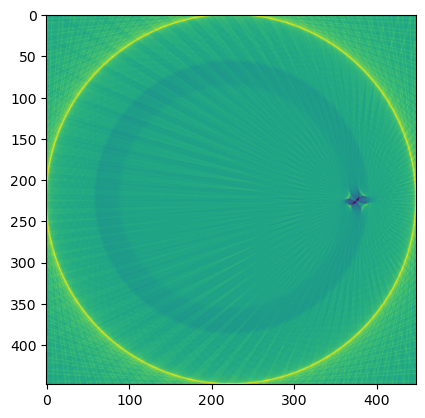

In [39]:
plt.imshow(reconstruction[reconstruction.shape[0]//2])

## Adjusting

In [24]:
import numpy as np
import astra
from imageio import imread, imwrite
import os
import tifffile as tiff
projections = p_small
# Configuration parameters
distance_source_origin   = 395  # Distance from source to origin (object) (mm)
distance_origin_detector = 1320 - distance_source_origin  # Distance from origin (object)  to detector (mm)
detector_pixel_size      = 0.139  # Detector pixel size (mm)
detector_rows            = p_small.shape[0]  # Number of detector rows (pixels)
detector_cols            = p_small.shape[2]  # Number of detector columns (pixels)
num_of_projections       = p_small.shape[1]  # Number of projections
angles = np.linspace(0, 2 * np.pi, num=num_of_projections, endpoint=True)  # Projection angles

detector_pixel_size_in_origin = detector_pixel_size * distance_source_origin / (distance_source_origin + distance_origin_detector)

proj_geom = astra.create_proj_geom(
    'cone',
    1, 1,
    detector_rows, detector_cols,
    -angles,
    distance_source_origin/detector_pixel_size ,
    0
)

# Apply the center of rotation correction
proj_geom = astra.geom_postalignment(proj_geom, factor=(3)) #passing the COR offset

# Create ASTRA data object for projections
projections_id = astra.data3d.create('-sino', proj_geom, projections)

# Create ASTRA volume geometry
vol_geom = astra.creators.create_vol_geom(detector_cols, detector_cols, detector_rows)

# Create ASTRA data object for reconstruction
reconstruction_id = astra.data3d.create('-vol', vol_geom, data=0)

# Configure the FDK algorithm
alg_cfg = astra.astra_dict('FDK_CUDA')
alg_cfg['ProjectionDataId'] = projections_id
alg_cfg['ReconstructionDataId'] = reconstruction_id

# Create and run the algorithm
algorithm_id = astra.algorithm.create(alg_cfg)
print("#######running FDK##########")
astra.algorithm.run(algorithm_id)
print("#######finnished FDK##########")

# Retrieve the reconstructed volume
reconstruction = astra.data3d.get(reconstruction_id)

# Post-processing: normalize
reconstruction /= np.max(reconstruction)


#######running FDK##########
#######finnished FDK##########


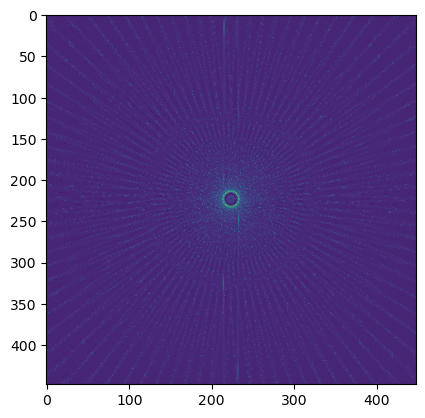

In [25]:
plt.imshow(reconstruction[reconstruction.shape[0]//2])